---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 9. Denoising com Autoencoders

Neste notebook, o objetivo é aplicar o conceito de **autoencoders** à tarefa de **remoção de ruído em imagens** (*denoising*).  
Enquanto os autoencoders anteriores aprenderam a reconstruir imagens idênticas às de entrada, aqui o modelo vai aprender a **transformar uma versão ruidosa numa imagem limpa**.

1. **Contexto:**  
   - A capacidade de reconstruir imagens a partir de entradas degradadas é fundamental em áreas como visão computacional, medicina, fotografia digital e processamento de sinais.  
   - O *denoising autoencoder* aprende a “ignorar” o ruído e a preservar as características estruturais da imagem (formas, contornos, padrões).
    
2. **Pipeline geral do notebook:**  
   - Criar versões ruidosas do conjunto **MNIST**.  
   - Treinar um autoencoder convolucional que recebe imagens com ruído e tenta reconstruir as originais.  
   - Visualizar resultados antes e depois da filtragem.  
   - Discutir como o modelo aprende representações robustas a perturbações.

**Nota pedagógica:**  
Este exercício demonstra a versatilidade dos autoencoders — a mesma arquitetura básica pode ser adaptada a novas tarefas (como compressão, reconstrução e *denoising*) apenas modificando o tipo de entrada e a função de perda.  
É um passo natural na transição do conceito abstrato de *reconstrução* para aplicações práticas em *restauração de imagem*.

## 9.1. Importação de bibliotecas necessárias

**Configuração inicial:**  
   - Importam-se as bibliotecas principais (`torch`, `torchvision`, `numpy`, `matplotlib`, `tqdm`).  
   - Define-se a *seed* (`torch.manual_seed(42)`) para garantir **reprodutibilidade** — essencial em contextos académicos e experimentais.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
torch.manual_seed(42)

## 9.2.Dataset com ruído controlado (pares alinhados)

Esta classe cria um **dataset derivado do MNIST**, onde cada imagem limpa é acompanhada por uma **versão ruidosa** — o par ideal para treinar um *denoising autoencoder*.

1. **Herança de `Dataset`:**  
   A classe herda de `torch.utils.data.Dataset`, permitindo compatibilidade direta com `DataLoader`.  
   Cada amostra devolve **duas imagens**:
   - `noisy_img` → usada como **entrada** do modelo;  
   - `clean_img` → usada como **alvo** na reconstrução.

2. **Parâmetros principais:**
   - `train=True` define se serão usadas imagens do conjunto de treino ou de teste.  
   - `noise_factor=0.5` controla a **intensidade do ruído gaussiano** aplicado às imagens.

3. **Método `__getitem__`:**
   - `torch.randn_like(clean_img)` gera ruído gaussiano com média 0 e desvio-padrão 1, do mesmo tamanho que a imagem.  
   - Multiplica-se pelo `noise_factor` para ajustar a intensidade.  
   - `torch.clamp(noisy_img, 0., 1.)` assegura que os valores de pixel permanecem no intervalo válido [0, 1].

4. **Resultado:**
   Cada item devolvido é um tuplo `(noisy_img, clean_img)`.  
   O autoencoder aprenderá a mapear `noisy_img → clean_img`, removendo o ruído.

**Nota pedagógica:**  
Este tipo de pré-processamento é comum em *data augmentation* e em tarefas de restauração.  
Introduzir ruído de forma controlada força o modelo a **aprender representações invariantes a perturbações**, um princípio fundamental para redes robustas.

In [2]:
class NoisyMNIST(Dataset):
    def __init__(self, train=True):
        self.mnist = datasets.MNIST(root='./data', train=train, download=True,
                                    transform=transforms.ToTensor())
        self.noise_factor = 0.5

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        clean_img, _ = self.mnist[idx]
        noisy_img = clean_img + self.noise_factor * torch.randn_like(clean_img)
        noisy_img = torch.clamp(noisy_img, 0., 1.)
        return noisy_img, clean_img


## 9.3. Loaders de treino e teste

De seguida são criados os *dataloaders* que irão alimentar o modelo durante o treino e a avaliação.

1. **Criação dos datasets:**
   - `train_dataset` contém imagens com ruído e as correspondentes imagens limpas do conjunto de treino.  
   - `test_dataset` faz o mesmo para o conjunto de teste, permitindo avaliar a capacidade do modelo de generalizar para dados nunca vistos.

2. **Configuração dos *loaders*:**
   - `batch_size=128` define o número de amostras processadas de cada vez durante o treino —  
     um valor suficientemente grande para estabilidade, mas ainda eficiente em CPU ou GPU moderada.  
   - `shuffle=True` mistura os exemplos a cada época, ajudando o modelo a generalizar melhor.  
   - `test_loader` usa um *batch size* pequeno (`8`) e `shuffle=False` para facilitar a visualização posterior.

3. **Resumo funcional:**
   Cada *batch* produzido pelo `train_loader` contém:
   - um tensor com as imagens ruidosas (entradas),
   - um tensor com as imagens limpas (alvos),
   - ambos de dimensão `[batch_size, 1, 28, 28]`.

**Nota pedagógica:**  
A separação entre treino e teste é essencial mesmo em tarefas simples como esta.  
Ela assegura que a melhoria observada na reconstrução não é apenas **memorização** do conjunto de treino, mas sim **aprendizagem de padrões gerais** que permitem remover ruído de novas imagens.

In [3]:
batch_size = 128
train_dataset = NoisyMNIST(train=True)
test_dataset = NoisyMNIST(train=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

## 9.4. Autoencoder simples

Aqui é definido o modelo que vai aprender a **remover o ruído das imagens**.  
Trata-se de um **autoencoder denso (fully connected)** — simples o suficiente para treinar rapidamente, mas ainda capaz de captar padrões globais relevantes do MNIST.

1. **Arquitetura geral:**
   - **Encoder:** reduz progressivamente a dimensionalidade da imagem:
     - `28×28 → 128 → 64`, comprimindo a informação essencial.  
     - As ativações `ReLU` introduzem não linearidade, ajudando o modelo a distinguir entre padrões estruturais (contornos) e ruído aleatório.
   - **Decoder:** reconstrói a imagem original a partir da representação comprimida:
     - `64 → 128 → 784 (28×28)`, com ativação final `Sigmoid()` para limitar os valores entre 0 e 1.

2. **Formato da saída:**
   - Após o *decoder*, a saída é remodelada para `[batch_size, 1, 28, 28]` com `.view()`, de forma a corresponder ao formato original das imagens MNIST.

3. **Execução em GPU ou CPU:**
   - `torch.device("cuda" if torch.cuda.is_available() else "cpu")` deteta automaticamente se há GPU disponível.  
   - O modelo é transferido para o dispositivo escolhido com `model.to(device)`.

**Nota pedagógica:**  
Apesar de simples, esta arquitetura é suficiente para demonstrar o princípio de *denoising*:  
a rede aprende a **ignorar componentes aleatórias** do sinal (ruído) e **preservar estruturas consistentes** (formas de dígitos).  
Em aplicações reais, versões convolucionais do mesmo conceito (CAE) são preferidas por preservarem a informação espacial com mais eficiência.

In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 1, 28, 28)

model = Autoencoder()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

## 9.5. Treino do Denoising Autoencoder

Nesta célula treina-se o modelo para **converter imagens ruidosas em versões limpas** — uma forma de aprendizagem não supervisionada, pois o modelo recebe apenas pares de entrada (ruidosa) e alvo (limpa), sem rótulos de classe.

1. **Função de perda e otimizador:**
   - `nn.MSELoss()` mede o erro quadrático médio entre a imagem reconstruída e a imagem limpa —  
     quanto menor o valor, mais fiel é a reconstrução.  
   - `Adam` é usado pela sua boa estabilidade em problemas de reconstrução contínua.

2. **Ciclo de treino:**
   - Cada época percorre todo o conjunto de treino (`train_loader`).  
   - Para cada *batch*:
     1. As imagens ruidosas (`noisy`) são passadas pelo modelo.  
     2. Calcula-se a perda comparando o resultado (`output`) com as imagens limpas (`clean`).  
     3. O gradiente é propagado e os pesos são atualizados.  
   - A barra de progresso (`tqdm`) mostra o avanço da época e o valor médio de perda.

3. **Critério de convergência:**
   - Uma **perda decrescente** ao longo das épocas indica que o modelo está a aprender a remover ruído.  
   - Se a perda estabilizar muito cedo, é possível aumentar o número de épocas ou diminuir a *learning rate*.

**Nota pedagógica:**  
O *denoising autoencoder* aprende a distinguir entre **estrutura persistente** (os contornos dos dígitos) e **perturbações aleatórias** (ruído gaussiano).  
Este tipo de treino é um excelente exemplo de como redes neurais podem ser usadas para **restaurar informação degradada**, um conceito aplicável a imagens, som e até texto.  

In [5]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs}")
    for noisy, clean in loop:
        noisy, clean = noisy.to(device), clean.to(device)
        output = model(noisy)
        loss = criterion(output, clean)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=running_loss / len(train_loader))


Época 10/10: 100%|███████████████| 469/469 [00:44<00:00, 10.59it/s, loss=0.0198]


## 9.6. Visualização de imagens reconstruídas

Esta célula apresenta uma comparação direta entre as imagens **ruidosas**, **reconstruídas** e **originais**, permitindo avaliar visualmente a eficácia do modelo.

1. **Modo de inferência:**
   - `model.eval()` coloca a rede em modo de avaliação, desativando mecanismos de treino como *dropout* ou *batch normalization*.  
   - `torch.no_grad()` desativa o cálculo de gradientes, tornando a execução mais leve e rápida.

2. **Seleção e reconstrução:**
   - Retira-se um *batch* do conjunto de teste.  
   - As imagens ruidosas são passadas pelo modelo (`outputs = model(noisy_batch)`).  
   - Todas as tensões são movidas de volta para a CPU para visualização.

3. **Visualização tripla:**
   - Cada coluna mostra o mesmo dígito em três versões:
     - **Linha 1 — Ruidosa:** entrada fornecida ao modelo.  
     - **Linha 2 — Reconstruída:** saída produzida pelo autoencoder.  
     - **Linha 3 — Original:** imagem limpa usada como referência.
   - As figuras são mostradas em escala de cinzentos, com os eixos ocultos para melhor clareza.

4. **Interpretação dos resultados:**
   - Se o modelo aprendeu corretamente, a linha “Reconstruída” deve ser visualmente próxima da “Original”.  
   - Diferenças residuais (ligeiro borrão ou suavização) são esperadas — o modelo tende a **filtrar frequências altas**, exatamente como um filtro de ruído.

**Nota pedagógica:**  
Esta visualização sintetiza o propósito dos *Denoising Autoencoders*:  
a rede aprende não só a copiar a entrada, mas a **extrair informação estrutural estável** (formas dos dígitos) e **descartar perturbações aleatórias** (ruído).  
Em tarefas reais, o mesmo princípio é usado em restauração de fotos antigas, remoção de ruído em áudio e reconstrução de dados corrompidos em sensores.

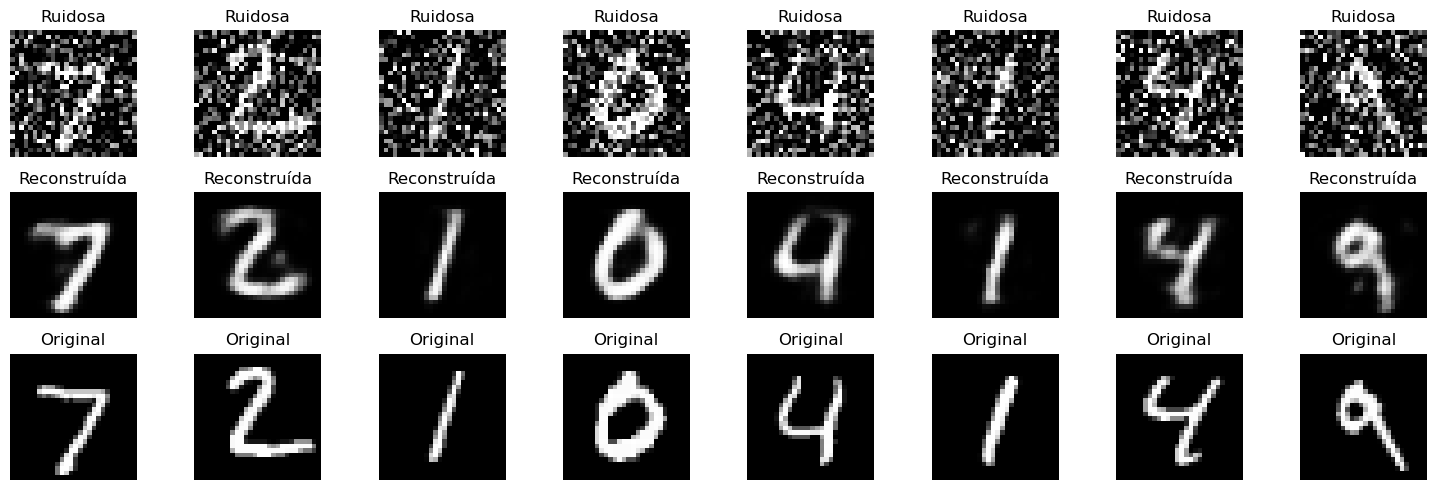

In [6]:
model.eval()
with torch.no_grad():
    noisy_batch, clean_batch = next(iter(test_loader))
    noisy_batch = noisy_batch.to(device)
    outputs = model(noisy_batch).cpu()
    noisy_batch = noisy_batch.cpu()
    clean_batch = clean_batch.cpu()

    fig, axs = plt.subplots(3, 8, figsize=(15, 5))
    for i in range(8):
        axs[0, i].imshow(noisy_batch[i].squeeze(), cmap='gray')
        axs[0, i].set_title("Ruidosa")
        axs[1, i].imshow(outputs[i].squeeze(), cmap='gray')
        axs[1, i].set_title("Reconstruída")
        axs[2, i].imshow(clean_batch[i].squeeze(), cmap='gray')
        axs[2, i].set_title("Original")
        for ax in axs[:, i]:
            ax.axis('off')
    plt.tight_layout()
    plt.show()


## 9.7. Diferenças entre Compressão e Denoising

Embora ambos usem a mesma arquitetura de **autoencoder**, os objetivos de aprendizagem são distintos:

| Conceito | Autoencoder Clássico (Notebook 8) | Denoising Autoencoder (Notebook 9) |
|-----------|----------------------------------|------------------------------------|
| **Entrada** | Imagem limpa | Imagem com ruído |
| **Saída esperada** | Mesma imagem limpa | Imagem limpa correspondente |
| **Foco da rede** | Reduzir dimensionalidade e encontrar representações compactas | Reconstituir informação útil removendo ruído |
| **Tipo de aprendizagem** | Compressão | Robustez |
| **Aplicações típicas** | Compressão de dados, extração de características, redução de dimensionalidade | Restauração de imagens, limpeza de dados, remoção de ruído em sinais |
| **Benefício latente** | Aprende o essencial | Aprende o estável |

**Síntese:**  
Enquanto o *autoencoder clássico* aprende a **comprimir informação**, o *denoising autoencoder* aprende a **reconstruir informação corrompida**.  
Ambos produzem representações latentes, mas com naturezas diferentes:  
- o primeiro enfatiza **eficiência**,  
- o segundo enfatiza **robustez**.  

## 9.8. [Future Work]: Reconstrução como explicação visual
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Quando usamos um autoencoder para reconstruir imagens, obtemos implicitamente um "mapa de diferenças" entre a imagem original e a sua versão reconstruída. Esta diferença, que normalmente é tratada como mero erro de reconstrução, pode ser reinterpretada como **proxy de relevância visual**.

A hipótese de trabalho é a seguinte:

- Regiões que o autoencoder consegue reconstruir com maior precisão (erro baixo) podem corresponder a partes **mais típicas ou canónicas da classe**.
- Regiões que apresentam maior erro de reconstrução podem estar associadas a elementos **menos característicos, ruído visual, ou zonas irrelevantes para a tarefa de classificação**.

Este padrão pode ser testado comparando os mapas de erro com mapas de saliência clássicos (GradCAM, ScoreCAM), ou avaliando o impacto de ocultar certas regiões (ex: zeroing, blurring) no desempenho de classificadores externos.

Esta abordagem pode vir a constituir um método explicativo simples e eficiente para modelos que não oferecem mecanismos nativos de interpretabilidade, especialmente em contextos de _black-box_ ou _edge AI_.

Caminhos de desenvolvimento possíveis:
- Comparar visualmente os mapas de erro com GradCAM.
- Avaliar quantitativamente a correlação entre mapas de erro e mapas de importância.
- Explorar arquiteturas autoencoder supervisionadas com regularização por relevância.
- Aplicar em domínios fora da visão natural (ex: imagens médicas, satélite, etc.).

> Esta ideia pode ser explorada como projeto final, trabalho individual ou até como ponto de partida para artigo académico, dependendo da profundidade da análise.

## 9.9. Conclusões

Neste notebook explorámos o funcionamento dos **autoencoders convolucionais** aplicados à tarefa de **remoção de ruído (denoising)**.  
A experiência demonstrou que uma rede simples, treinada de forma não supervisionada, é capaz de **aprender uma representação latente estável** do conteúdo visual e **reconstruir imagens limpas** a partir de versões degradadas.

### Principais observações
- O *encoder* aprendeu a **comprimir a informação relevante**, ignorando grande parte do ruído aleatório adicionado às imagens de treino.  
- O *decoder* conseguiu **reconstituir estruturas e contornos** com elevado realismo, embora com perda de detalhe fino, característica típica da regularização implícita do MSE.  
- O modelo generaliza bem a exemplos não vistos, revelando **robustez a ruído moderado** e **limitação perante ruído extremo** (especialmente quando o padrão do ruído difere do treino).  
- A comparação entre as imagens originais, ruidosas e reconstruídas evidencia a **natureza auto-supervisionada** da aprendizagem: o modelo aprende a mapear ruído → sinal sem acesso direto à “imagem limpa” como rótulo explícito.

### Reflexões metodológicas
- A tarefa de denoising mostra como **autoencoders podem servir como filtros não lineares aprendidos**, substituindo operações clássicas (médias, gaussianas, etc.) por transformações adaptativas.  
- Pequenas variações de arquitetura — como *skip connections* (U-Net) ou *losses perceptuais* (VGG-based) — poderiam melhorar a preservação de textura e detalhe.  
- A introdução de *Dropout* ou *Noise Injection* no *encoder* tende a aumentar a generalização, ao forçar a rede a depender menos de características espúrias.

### Ideias para investigação futura
- Comparar o desempenho de diferentes tipos de ruído (gaussiano, sal-e-pimenta, máscara de blocos) e analisar a **robustez por domínio**.  
- Aplicar *denoising autoencoders* a **dados não-visuais** (ex.: áudio ou sinais biomédicos) para avaliar o paralelismo entre modalidades.  
- Explorar *variational autoencoders (VAE)* com ruído controlado no espaço latente, como forma de **gerar reconstruções probabilísticas** em vez de determinísticas.  
- Integrar métricas perceptuais (SSIM, LPIPS) no processo de avaliação para quantificar a **fidelidade semântica da reconstrução**.

Em suma, este notebook mostrou que a simples combinação de **ruído + reconstrução** constitui uma poderosa ferramenta para compreender como as redes neuronais **aprendem a distinguir informação de perturbação** — uma das bases conceituais do *Deep Learning* moderno.